In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses
from varengine.historical import hs_var, hs_es, rolling_hs

In [2]:
from varengine.config import TICKERS, START, END
prices = load_prices(TICKERS, START, END)

rets = simple_returns(prices)
w = np.full(len(TICKERS), 1 / len(TICKERS))
loss = portfolio_losses(rets, w)

Loaded cached prices: 2015-01-02 to 2026-09-18


In [3]:
print(loss.shape)

(2995,)


In [4]:
print(loss.index[0], loss.index[-1])

2015-01-05 00:00:00 2026-09-18 00:00:00


In [5]:
print(len(prices), len(loss))
gaps = loss.index.to_series().diff().dt.days
print(gaps.value_counts().head()) # normal = mostly 1s and 3s (weekends)
print(gaps.nlargest(5)) # where the days are missing and where they end

2996 2995
Date
1.0    2371
3.0     582
5.0      15
4.0      15
2.0      11
Name: count, dtype: int64
Date
2015-04-07    5.0
2016-03-29    5.0
2017-04-18    5.0
2017-12-27    5.0
2018-04-03    5.0
Name: Date, dtype: float64


In [6]:
# so we do have 2995 days and no days are missing: the 5 day gaps are Easter and Christmas

In [7]:
# checking examples from notes computed manually to verify
x = [0.4, -1.2, 2.1, 0.3, -0.5, 3.5, -0.8, 1.0, -2.0, 0.7]
print(hs_var(x, 0.80), hs_var(x, 0.85))   # should be 1 and 2.1
print(hs_es(x, 0.80))                     # shoule be 2.2

1.0 2.1
2.1999999999999997


In [8]:
rng = np.random.default_rng(0)
z = rng.standard_normal(1_000_000)
print(hs_var(z, 0.99), norm.ppf(0.99))
print(hs_es(z, 0.99), norm.pdf(norm.ppf(0.99)) / 0.01)

2.3311365011023155 2.3263478740408408
2.6648678958081953 2.665214220345808


In [9]:
res = rolling_hs(loss, window=500, alpha=0.99)
print(res.head())
print("first forecast date:", res.index[0], "| loss series starts:", loss.index[0])

                VaR        ES
Date                         
2016-12-14  0.04212  0.063167
2016-12-15  0.04212  0.063167
2016-12-16  0.04212  0.063167
2016-12-19  0.04212  0.063167
2016-12-20  0.04212  0.063167
first forecast date: 2016-12-14 00:00:00 | loss series starts: 2015-01-05 00:00:00


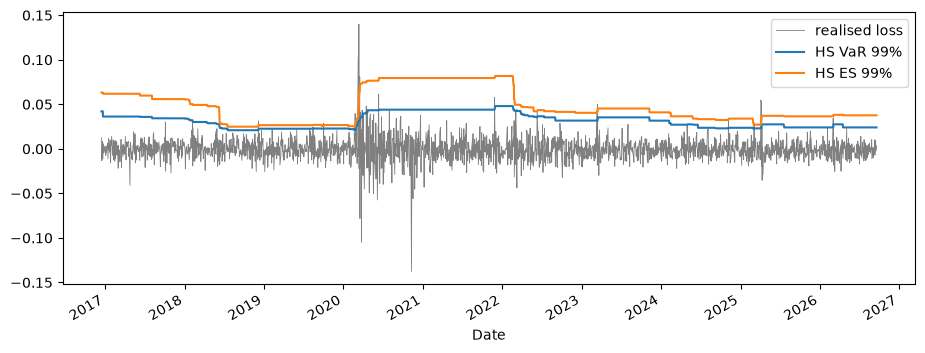

In [10]:
realised = loss.loc[res.index]

ax = realised.plot(figsize=(11, 4), lw=0.6, color="grey", label="realised loss")
res["VaR"].plot(ax=ax, label="HS VaR 99%")
res["ES"].plot(ax=ax, label="HS ES 99%")
ax.legend()
plt.show()

In [11]:
hits = realised > res["VaR"]
print(f"violations: {hits.sum()} of {len(hits)} days "
      f"({hits.mean():.2%}, expected 1.00%)")
print(hits.loc["2020"].sum(), "violations in 2020")

violations: 28 of 2495 days (1.12%, expected 1.00%)
14 violations in 2020
